# 4 · Runtime benchmark
Companion notebook to *Fast reconstruction of tensor tomographic X-ray scattering data for real-time applications*
(Mesquita Antunes, Pelt & Batenburg, Optics Express, [doi:10.1364/OE.597352](https://doi.org/10.1364/OE.597352)).

Runtimes of the Landweber and algebraic filter (AF) reconstructions as a function of the number of iterations, and
the resulting speed-ups (cf. Fig. 7). Timings are only meaningful on a GPU machine; the paper used an
NVIDIA RTX 4070 Super and an Intel Core i5-14600KF. Run notebooks 01 and 02 first.

In [1]:
# Colab only: fetch the repository and install mumott (skipped everywhere else)
import os, sys
if 'google.colab' in sys.modules and not os.getcwd().endswith('notebooks'):
    !git clone -q https://github.com/mesqant/algebraic-filters-tt
    %pip install -q mumott==2.1 "scipy<1.17" colorcet
    %cd algebraic-filters-tt/notebooks

In [2]:
# Imports (mumott's INFO logging is silenced; its DeprecationWarnings about entry names in the phantom file are harmless)
import logging
import time
import warnings
from concurrent.futures import ThreadPoolExecutor
from functools import partial
from pathlib import Path
import numpy as np
import scipy.fft
import scipy.signal
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
logging.getLogger('mumott').setLevel(logging.WARNING)
from mumott.data_handling import DataContainer
from mumott.methods.projectors import SAXSProjector, SAXSProjectorCUDA

In [3]:
# Compute backend: GPU (cupy + mumott's CUDA projector) if available, else CPU (numpy + mumott's numba projector)
try:
    import cupy as cp
    gpu_available = cp.cuda.runtime.getDeviceCount() > 0
except Exception:
    gpu_available = False
xp = cp if gpu_available else np
to_numpy = cp.asnumpy if gpu_available else np.asarray  # device → host copy (no-op on CPU)
if not gpu_available:
    warnings.warn('No GPU found: running a reduced CPU benchmark whose timings are not comparable to the paper.')
f'GPU: {gpu_available}'

'GPU: True'

In [4]:
# Build the previous notebooks' outputs if they are missing (e.g. on a fresh Colab runtime)
data_dir = Path('../data')
for notebook, output in [('01_representations', 'phantom_representations.npz'), ('02_forward_models', 'mixing_operators.npz')]:
    if not (data_dir / output).exists():
        !jupyter nbconvert --to notebook --execute {notebook}.ipynb --output-dir /tmp

In [5]:
# Load the phantom representations (notebook 01) and mixing operators (notebook 02)
phantom = np.load(data_dir / 'phantom_representations.npz')
mixing = np.load(data_dir / 'mixing_operators.npz')
volume_shape = phantom['tensor'].shape[:3]
view_step = int(mixing['view_step'])
volume_shape, view_step

((57, 57, 57), 1)

In [6]:
# Benchmark settings: all representations and iteration counts of Fig. 7 on GPU, a reduced set on CPU
full_benchmark = gpu_available and view_step == 1
representations = ['spherical', 'directional', 'tensor'] if full_benchmark else ['tensor']
iteration_counts = [5, 10, 25, 50, 100, 150, 200] if full_benchmark else [5, 10, 25, 50]
k_filters = 50       # iterations used for the filters (the AF runtime does not depend on k)
n_repeats = 7        # AF timing repeats
workers = min(10, os.cpu_count())  # threads for the FFT filtering (the paper used 10)
representations, iteration_counts, workers

(['spherical', 'directional', 'tensor'], [5, 10, 25, 50, 100, 150, 200], 10)

## Forward model (as in notebook 02)

In [7]:
# Acquisition geometry, resized to the padded volume and subsampled like in notebook 02
geometry = DataContainer(str(data_dir / 'M_sim_1.0e+01.h5')).geometry
geometry.volume_shape = volume_shape
geometry.projection_shape = volume_shape[:2]
for view in reversed(range(len(geometry))):
    if view % view_step:
        del geometry[view]
len(geometry)

417

In [8]:
# Tomographic projector W̄, forward model A = W̄Y and adjoint Aᵀ = YᵀW̄ᵀ
projector = SAXSProjectorCUDA(geometry) if gpu_available else SAXSProjector(geometry)

def to_projector(array):  # mumott projectors take host arrays (float32 for CUDA, float64 for CPU)
    return np.asarray(to_numpy(array), dtype=projector.dtype)

def forward(volume, mixing):
    projections = xp.asarray(projector.forward(to_projector(volume)), dtype=xp.float32)
    return xp.einsum('vijc,vsc->vijs', projections, mixing)

def backward(projections, mixing):
    unmixed = xp.einsum('vijs,vsc->vijc', projections, mixing)
    return xp.asarray(projector.adjoint(to_projector(unmixed)), dtype=xp.float32)

## Reconstruction methods (as in notebook 03)

In [9]:
# Landweber step size from 8 power iterations on the back-projected data
def estimate_alpha(A, At, b):
    v = At(b)
    v /= xp.linalg.norm(v)
    for _ in range(8):
        w = At(A(v))
        lam = float(xp.vdot(v, w))
        v = w / xp.linalg.norm(w)
    return 1.9 / lam

In [10]:
# Landweber reconstruction α Σ_{i=0}^{k} (I − αAᵀA)^i Aᵀb (same k+1 term convention as notebook 03)
# Note: the paper's timings also tracked the residual norm at every iteration, which is omitted here (negligible cost).
def landweber(A, At, b, k, alpha):
    term = At(b)
    total = term.copy()
    for _ in range(k):
        term -= alpha * At(A(term))
        total += term
    return alpha * total

In [11]:
# Algebraic filters q_c = Qᵀδ_c for all components (reused from notebook 03's cache when available)
def compute_filters(A, At, x_shape, b_shape, k, alpha, path):
    if path.exists():
        return np.load(path)
    filters = np.empty((x_shape[-1],) + b_shape, dtype=np.float32)
    for c in tqdm(range(x_shape[-1]), desc='Filters', leave=False):
        term = xp.zeros(x_shape, dtype=xp.float32)
        term[x_shape[0] // 2, x_shape[1] // 2, x_shape[2] // 2, c] = 1
        total = term.copy()
        for _ in range(k):
            term -= alpha * At(A(term))
            total += term
        filters[c] = to_numpy(alpha * A(total))
    np.save(path, filters)
    return filters

In [12]:
# AF reconstruction as timed in the paper: multithreaded FFT convolution of every (view, component) pair, summed over
# channels ('same'-size output), followed by one back-projection W̄ᵀ
def af_reconstruct(b_host, filters):
    n_views, N, _, n_channels = b_host.shape
    n_components = filters.shape[0]
    fft_shape = [scipy.fft.next_fast_len(2 * N - 1)] * 2
    crop = slice((N - 1) // 2, (N - 1) // 2 + N)
    b_fft = np.empty((n_views, fft_shape[0], fft_shape[1] // 2 + 1, n_channels), dtype=np.complex64)
    filtered = np.empty((n_views, N, N, n_components), dtype=np.float32)

    def transform_projection(v):
        b_fft[v] = scipy.fft.rfftn(b_host[v], fft_shape, axes=(0, 1))

    def filter_pair(index):
        v, c = divmod(index, n_components)
        product = b_fft[v] * scipy.fft.rfftn(filters[c, v], fft_shape, axes=(0, 1))
        filtered[v, :, :, c] = scipy.fft.irfftn(product, fft_shape, axes=(0, 1))[crop, crop].sum(axis=-1)

    with ThreadPoolExecutor(max_workers=workers) as executor:
        list(executor.map(transform_projection, range(n_views)))
    with ThreadPoolExecutor(max_workers=workers) as executor:
        list(executor.map(filter_pair, range(n_views * n_components)))
    return projector.adjoint(to_projector(filtered))

In [13]:
# Wall-clock time of a call, waiting for the GPU to finish
def timed(function, *args):
    if gpu_available:
        cp.cuda.Device().synchronize()
    start = time.perf_counter()
    result = function(*args)
    if gpu_available:
        cp.cuda.Device().synchronize()
    return time.perf_counter() - start, result

## Check the fast AF reconstruction against notebook 03's `scipy.signal.fftconvolve` version

In [14]:
# Tensor representation: simulated projections, step size and filters
A = partial(forward, mixing=xp.asarray(mixing['tensor']))
At = partial(backward, mixing=xp.asarray(mixing['tensor']))
b = A(phantom['tensor'])
alpha = estimate_alpha(A, At, b)
filters = compute_filters(A, At, phantom['tensor'].shape, b.shape, k_filters, alpha,
                          data_dir / f'algebraic_filters_tensor_{k_filters}iter_{len(geometry)}views.npy')
b_host = to_numpy(b)
filters.shape

(6, 417, 57, 57, 3)

In [15]:
# Both reconstructions should agree to float32 precision
x_fast = af_reconstruct(b_host, filters)
filtered = np.stack([np.stack([scipy.signal.fftconvolve(b_host[v], filters[c, v], mode='same', axes=(0, 1)).sum(axis=-1)
                               for c in range(filters.shape[0])], axis=-1) for v in range(b_host.shape[0])])
x_reference = projector.adjoint(to_projector(filtered))
f'max relative difference: {np.abs(x_fast - x_reference).max() / np.abs(x_reference).max():.1e}'

'max relative difference: 0.0e+00'

## Timings

In [16]:
# Time Landweber for every iteration count and AF (median of repeats) for every representation
runtimes = {}
for representation in representations:
    A = partial(forward, mixing=xp.asarray(mixing[representation]))
    At = partial(backward, mixing=xp.asarray(mixing[representation]))
    b = A(phantom[representation])
    alpha = estimate_alpha(A, At, b)
    filters = compute_filters(A, At, phantom[representation].shape, b.shape, k_filters, alpha,
                              data_dir / f'algebraic_filters_{representation}_{k_filters}iter_{len(geometry)}views.npy')
    b_host = to_numpy(b)
    landweber(A, At, b, 1, alpha), af_reconstruct(b_host, filters)  # warm-up (compilation, caches)
    landweber_times = [timed(landweber, A, At, b, k, alpha)[0] for k in tqdm(iteration_counts, desc=f'Landweber ({representation})')]
    af_time = np.median([timed(af_reconstruct, b_host, filters)[0] for _ in range(n_repeats)])
    runtimes[representation] = {'landweber': np.array(landweber_times), 'af': af_time}
    print(f'{representation:12s} AF: {af_time:.3f} s   Landweber: {np.round(landweber_times, 2)} s')
    del filters

Filters:   0%|          | 0/28 [00:00<?, ?it/s]

Landweber (spherical):   0%|          | 0/7 [00:00<?, ?it/s]

spherical    AF: 1.050 s   Landweber: [ 0.68  1.29  3.12  6.17 12.27 18.42 24.51] s


Landweber (directional):   0%|          | 0/7 [00:00<?, ?it/s]

directional  AF: 0.358 s   Landweber: [ 0.36  0.68  1.64  3.25  6.45  9.68 12.88] s


Landweber (tensor):   0%|          | 0/7 [00:00<?, ?it/s]

tensor       AF: 0.249 s   Landweber: [ 0.32  0.61  1.46  2.9   5.75  8.61 11.48] s


In [17]:
# Save the runtimes
np.savez(data_dir / 'runtimes.npz', iteration_counts=iteration_counts,
         **{f'{rep}_{method}': value for rep, times in runtimes.items() for method, value in times.items()})

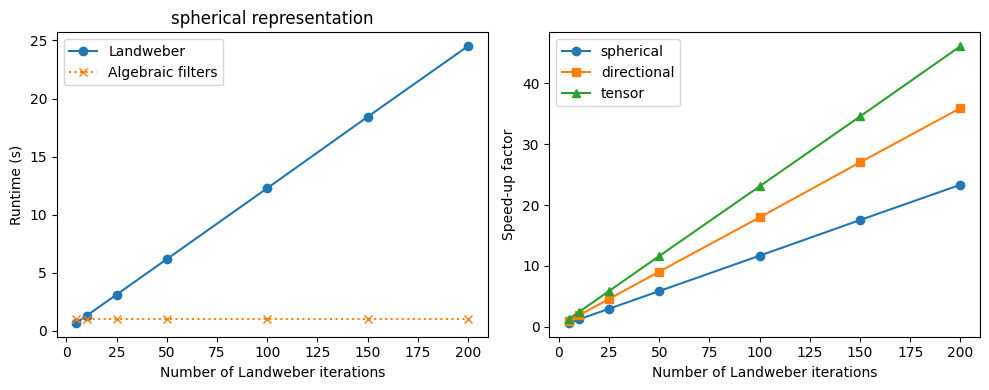

In [18]:
# Plot the runtimes of the first representation and the speed-ups of all representations (cf. Fig. 7)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)
first = representations[0]
axes[0].plot(iteration_counts, runtimes[first]['landweber'], 'o-', label='Landweber')
axes[0].plot(iteration_counts, [runtimes[first]['af']] * len(iteration_counts), 'x:', label='Algebraic filters')
axes[0].set(xlabel='Number of Landweber iterations', ylabel='Runtime (s)', title=f'{first} representation')
axes[0].legend()
for representation, marker in zip(representations, 'os^'):
    axes[1].plot(iteration_counts, runtimes[representation]['landweber'] / runtimes[representation]['af'], marker + '-', label=representation)
axes[1].set(xlabel='Number of Landweber iterations', ylabel='Speed-up factor')
axes[1].legend();